In [ ]:
from google.colab import files
uploaded = files.upload()

Saving combined_data(2025-3-1-2026-2-28) by channel and user.csv to combined_data(2025-3-1-2026-2-28) by channel and user.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Frammer Color Palette (Red on Black)
FRAMMER_COLORS = ["#7A0000", "#CC0000", "#FF3131", "#FF9A9A", "#FFD6D6", "#FFFFFF"]

# Global Plot Style : Black Background
plt.rcParams.update({
    "figure.facecolor"  : "#0D0D0D",
    "axes.facecolor"    : "#0D0D0D",
    "axes.edgecolor"    : "#444444",
    "axes.labelcolor"   : "#FFFFFF",
    "axes.titlecolor"   : "#FFFFFF",
    "xtick.color"       : "#FFFFFF",
    "ytick.color"       : "#FFFFFF",
    "text.color"        : "#FFFFFF",
    "grid.color"        : "#2A2A2A",
    "grid.linestyle"    : "--",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.dpi"        : 130,
    "font.family"       : "DejaVu Sans",
})

print("✅ Imports done | Black theme set | Palette ready")
print("   Colors:", FRAMMER_COLORS)

✅ Imports done | Black theme set | Palette ready
   Colors: ['#7A0000', '#CC0000', '#FF3131', '#FF9A9A', '#FFD6D6', '#FFFFFF']


In [ ]:
df = pd.read_csv("combined_data(2025-3-1-2026-2-28) by channel and user.csv")
df.info()

#To find the missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Channel                        236 non-null    object
 1   User                           236 non-null    object
 2   Uploaded Count                 236 non-null    int64 
 3   Created Count                  236 non-null    int64 
 4   Published Count                236 non-null    int64 
 5   Uploaded Duration (hh:mm:ss)   236 non-null    object
 6   Created Duration (hh:mm:ss)    236 non-null    object
 7   Published Duration (hh:mm:ss)  236 non-null    object
dtypes: int64(3), object(5)
memory usage: 14.9+ KB


,0
Channel,0
User,0
Uploaded Count,0
Created Count,0
Published Count,0
Uploaded Duration (hh:mm:ss),0
Created Duration (hh:mm:ss),0
Published Duration (hh:mm:ss),0


In [ ]:
df = df.copy()

# IMPORTANT: To remove Trailing Space
df["Channel"] = df["Channel"].astype(str).str.strip()
df["User"]    = df["User"].astype(str).str.strip()

# To Convert hh:mm:ss duration columns → total seconds
def hhmmss_to_seconds(series):
    def _parse(val):
        try:
            h, m, s = str(val).strip().split(":")
            return int(h) * 3600 + int(m) * 60 + int(s)
        except:
            return 0
    return series.apply(_parse)

df["uploaded_dur_sec"]  = hhmmss_to_seconds(df["Uploaded Duration (hh:mm:ss)"])
df["created_dur_sec"]   = hhmmss_to_seconds(df["Created Duration (hh:mm:ss)"])
df["published_dur_sec"] = hhmmss_to_seconds(df["Published Duration (hh:mm:ss)"])

# Rename
df.rename(columns={
    "Uploaded Count"  : "uploaded_cnt",
    "Created Count"   : "created_cnt",
    "Published Count" : "published_cnt",
}, inplace=True)

# Metric Definitions
# Publish Rate %  (avoid division by zero)
df["publish_rate_pct"] = np.where(
    df["created_cnt"] > 0,
    (df["published_cnt"] / df["created_cnt"] * 100).round(2),
    0.0
)

# Amplification Ratio — how many clips created per upload
df["amplification_ratio"] = np.where(
    df["uploaded_cnt"] > 0,
    (df["created_cnt"] / df["uploaded_cnt"]).round(2),
    0.0
)

# Remove internal or test accounts
TEST_KEYWORDS = ["test", "deleteme", "qa-", "frammer.com",
                 "moolya.com", "testaing.com", "theveritycorp.com"]

df["is_internal"] = df["User"].str.lower().apply(
    lambda u: any(kw in u for kw in TEST_KEYWORDS)
)

df_clean = df[df["is_internal"] == False].reset_index(drop=True)

print(f"✅ Preprocessing done")
print(f"   Rows: {len(df)} | Channels: {df['Channel'].nunique()} | Users: {df['User'].nunique()}")
print(f"   Internal accounts flagged: {df['is_internal'].sum()}")
print(f"   Rows after removing internal accounts: {len(df_clean)}")

✅ Preprocessing done
   Rows: 236 | Channels: 18 | Users: 45
   Internal accounts flagged: 56
   Rows after removing internal accounts: 180


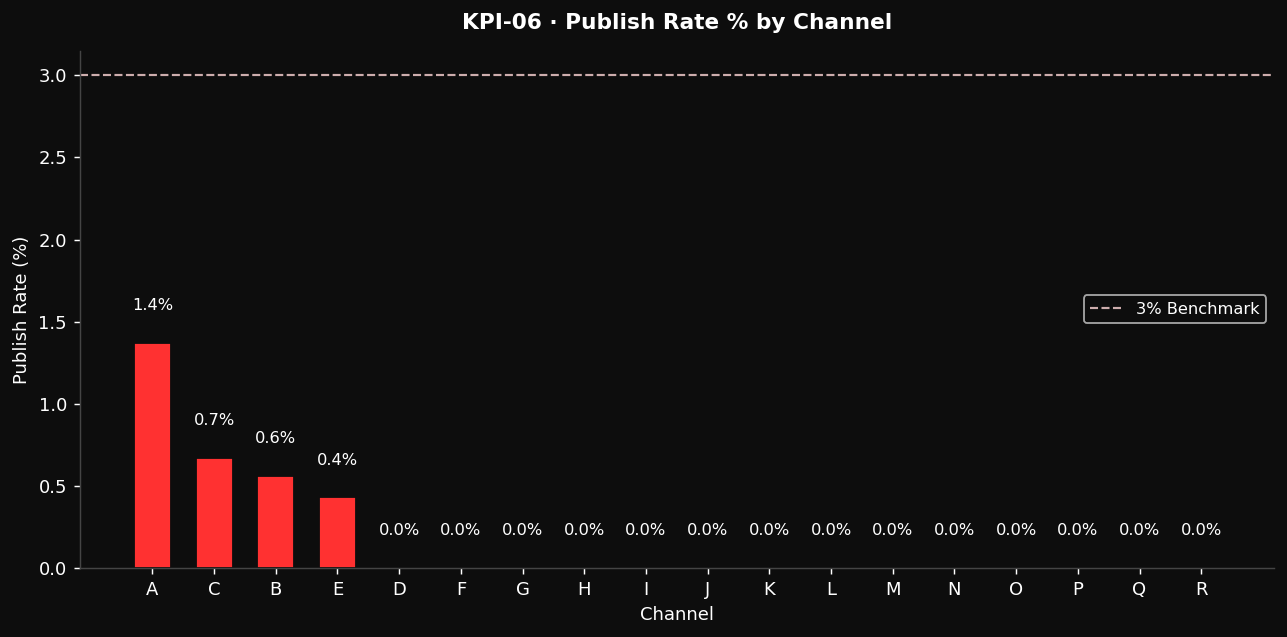

In [ ]:
# ── KPI-06 Calculation ────────────────────────────────────────────────────────
kpi06 = (
    df_clean.groupby("Channel")
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .assign(publish_rate_pct=lambda x:
            (x["total_published"] / x["total_created"] * 100).round(2))
    .reset_index()
    .sort_values("publish_rate_pct", ascending=False)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(kpi06["Channel"], kpi06["publish_rate_pct"],
              color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.6)

# Value labels on top of each bar
for bar, val in zip(bars, kpi06["publish_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", fontsize=9, color="#FFFFFF")

# 3% benchmark line
ax.axhline(3, color=FRAMMER_COLORS[4], linestyle="--",
           linewidth=1.2, alpha=0.8, label="3% Benchmark")

ax.set_xlabel("Channel")
ax.set_ylabel("Publish Rate (%)")
ax.set_title("KPI-06 · Publish Rate % by Channel",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.set_facecolor("#0D0D0D")
fig.patch.set_facecolor("#0D0D0D")

plt.tight_layout()
plt.show()

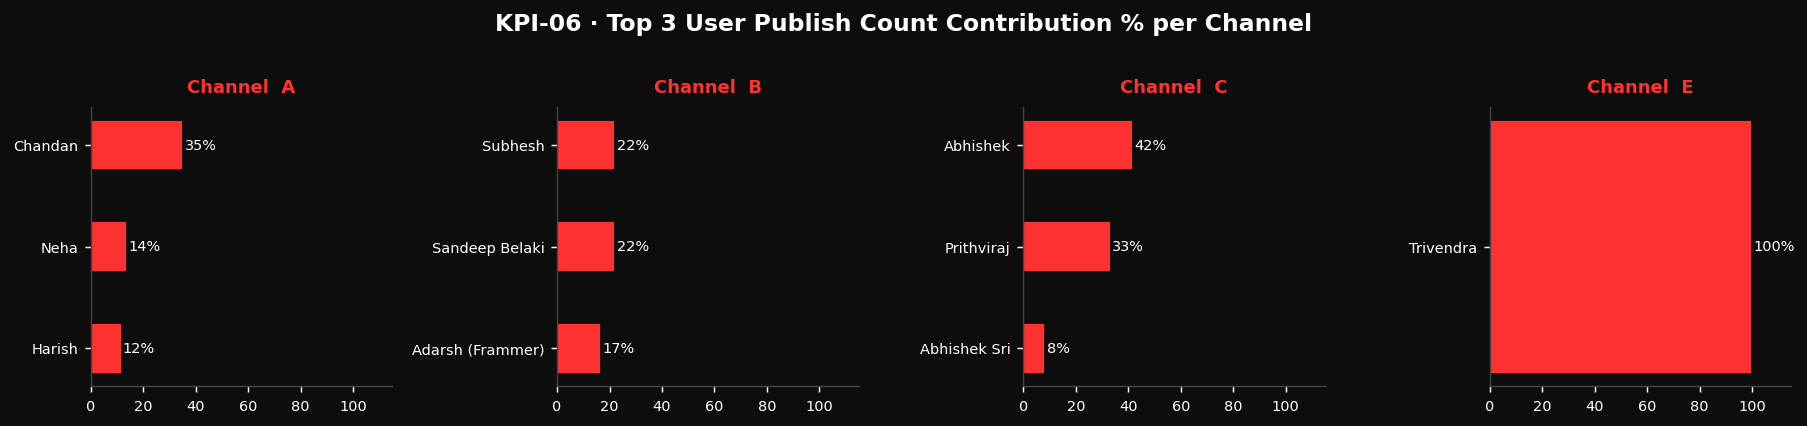

In [ ]:
# ── User Contribution % per Channel ──────────────────────────────────────────
user_contrib = (
    df_clean[df_clean["published_cnt"] > 0]
    .groupby(["Channel", "User"])["published_cnt"]
    .sum()
    .reset_index()
)

channel_total = user_contrib.groupby("Channel")["published_cnt"].sum().rename("channel_total")
user_contrib  = user_contrib.join(channel_total, on="Channel")
user_contrib["contribution_pct"] = (
    user_contrib["published_cnt"] / user_contrib["channel_total"] * 100
).round(2)

# ── Top 3 users per channel ───────────────────────────────────────────────────
top3 = (
    user_contrib.groupby("Channel")
    .apply(lambda g: g.nlargest(3, "contribution_pct"))
    .reset_index(drop=True)
)

channels = top3["Channel"].unique()
n_cols   = 4
n_rows   = int(np.ceil(len(channels) / n_cols))

# ── Small Multiples Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, n_rows * 3.2),
                          facecolor="#0D0D0D")
axes = axes.flatten()

for i, ch in enumerate(channels):
    ax  = axes[i]
    sub = top3[top3["Channel"] == ch].sort_values("contribution_pct", ascending=True)

    bars = ax.barh(sub["User"], sub["contribution_pct"],
                   color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", height=0.5)

    # Value labels
    for bar, val in zip(bars, sub["contribution_pct"]):
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%", va="center",
                fontsize=8, color="#FFFFFF")

    ax.set_title(f"Channel  {ch}", fontsize=10,
                 fontweight="bold", color="#FF3131", pad=8)
    ax.set_xlim(0, 115)
    ax.set_facecolor("#0D0D0D")
    ax.tick_params(colors="#FFFFFF", labelsize=8)
    ax.spines["bottom"].set_color("#444444")
    ax.spines["left"].set_color("#444444")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("KPI-06 · Top 3 User Publish Count Contribution % per Channel",
             fontsize=13, fontweight="bold",
             color="#FFFFFF", y=1.01)

plt.tight_layout()
plt.show()

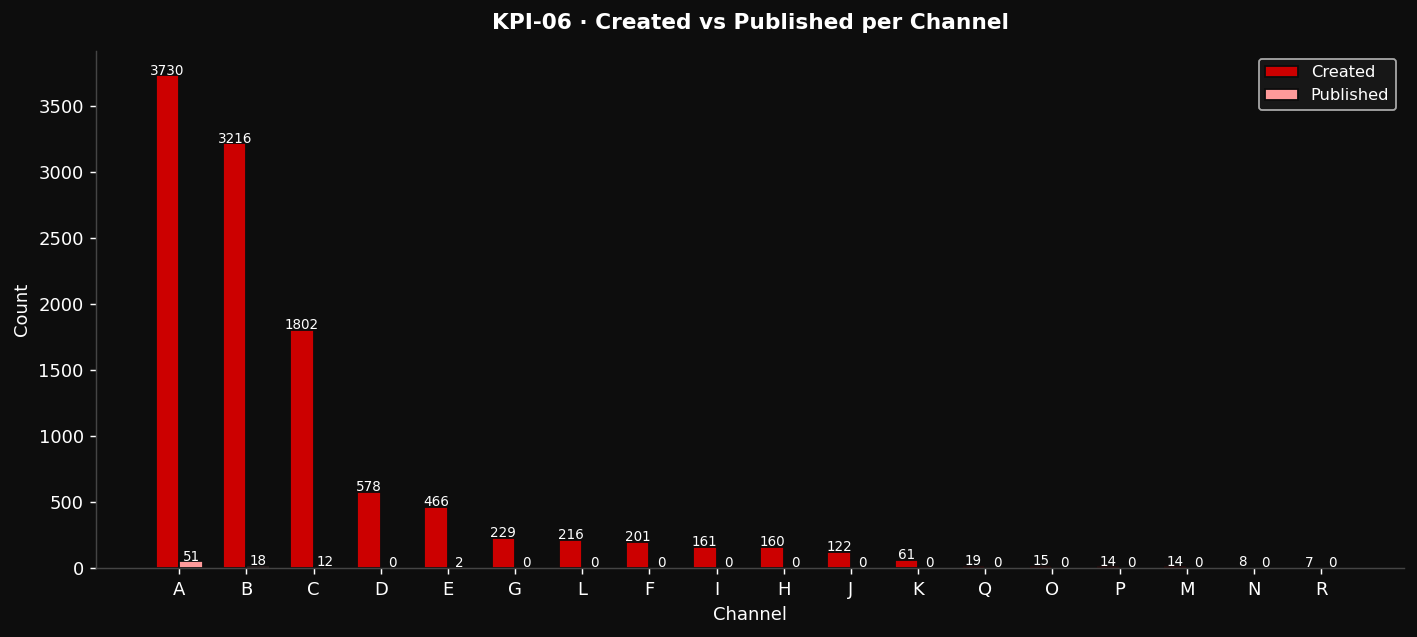

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi06_grouped = (
    df_clean.groupby("Channel")
    .agg(total_created  =("created_cnt",   "sum"),
         total_published=("published_cnt",  "sum"))
    .reset_index()
    .sort_values("total_created", ascending=False)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
x     = np.arange(len(kpi06_grouped))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2, kpi06_grouped["total_created"],
               width, color=FRAMMER_COLORS[1],
               edgecolor="#0D0D0D", label="Created")

bars2 = ax.bar(x + width/2, kpi06_grouped["total_published"],
               width, color=FRAMMER_COLORS[3],
               edgecolor="#0D0D0D", label="Published")

# Value labels on top
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha="center", fontsize=7.5, color="#FFFFFF")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha="center", fontsize=7.5, color="#FFFFFF")

ax.set_xticks(x)
ax.set_xticklabels(kpi06_grouped["Channel"], fontsize=10)
ax.set_ylabel("Count")
ax.set_xlabel("Channel")
ax.set_title("KPI-06 · Created vs Published per Channel",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, facecolor="#1A1A1A", labelcolor="#FFFFFF")
ax.set_facecolor("#0D0D0D")
fig.patch.set_facecolor("#0D0D0D")

plt.tight_layout()
plt.show()

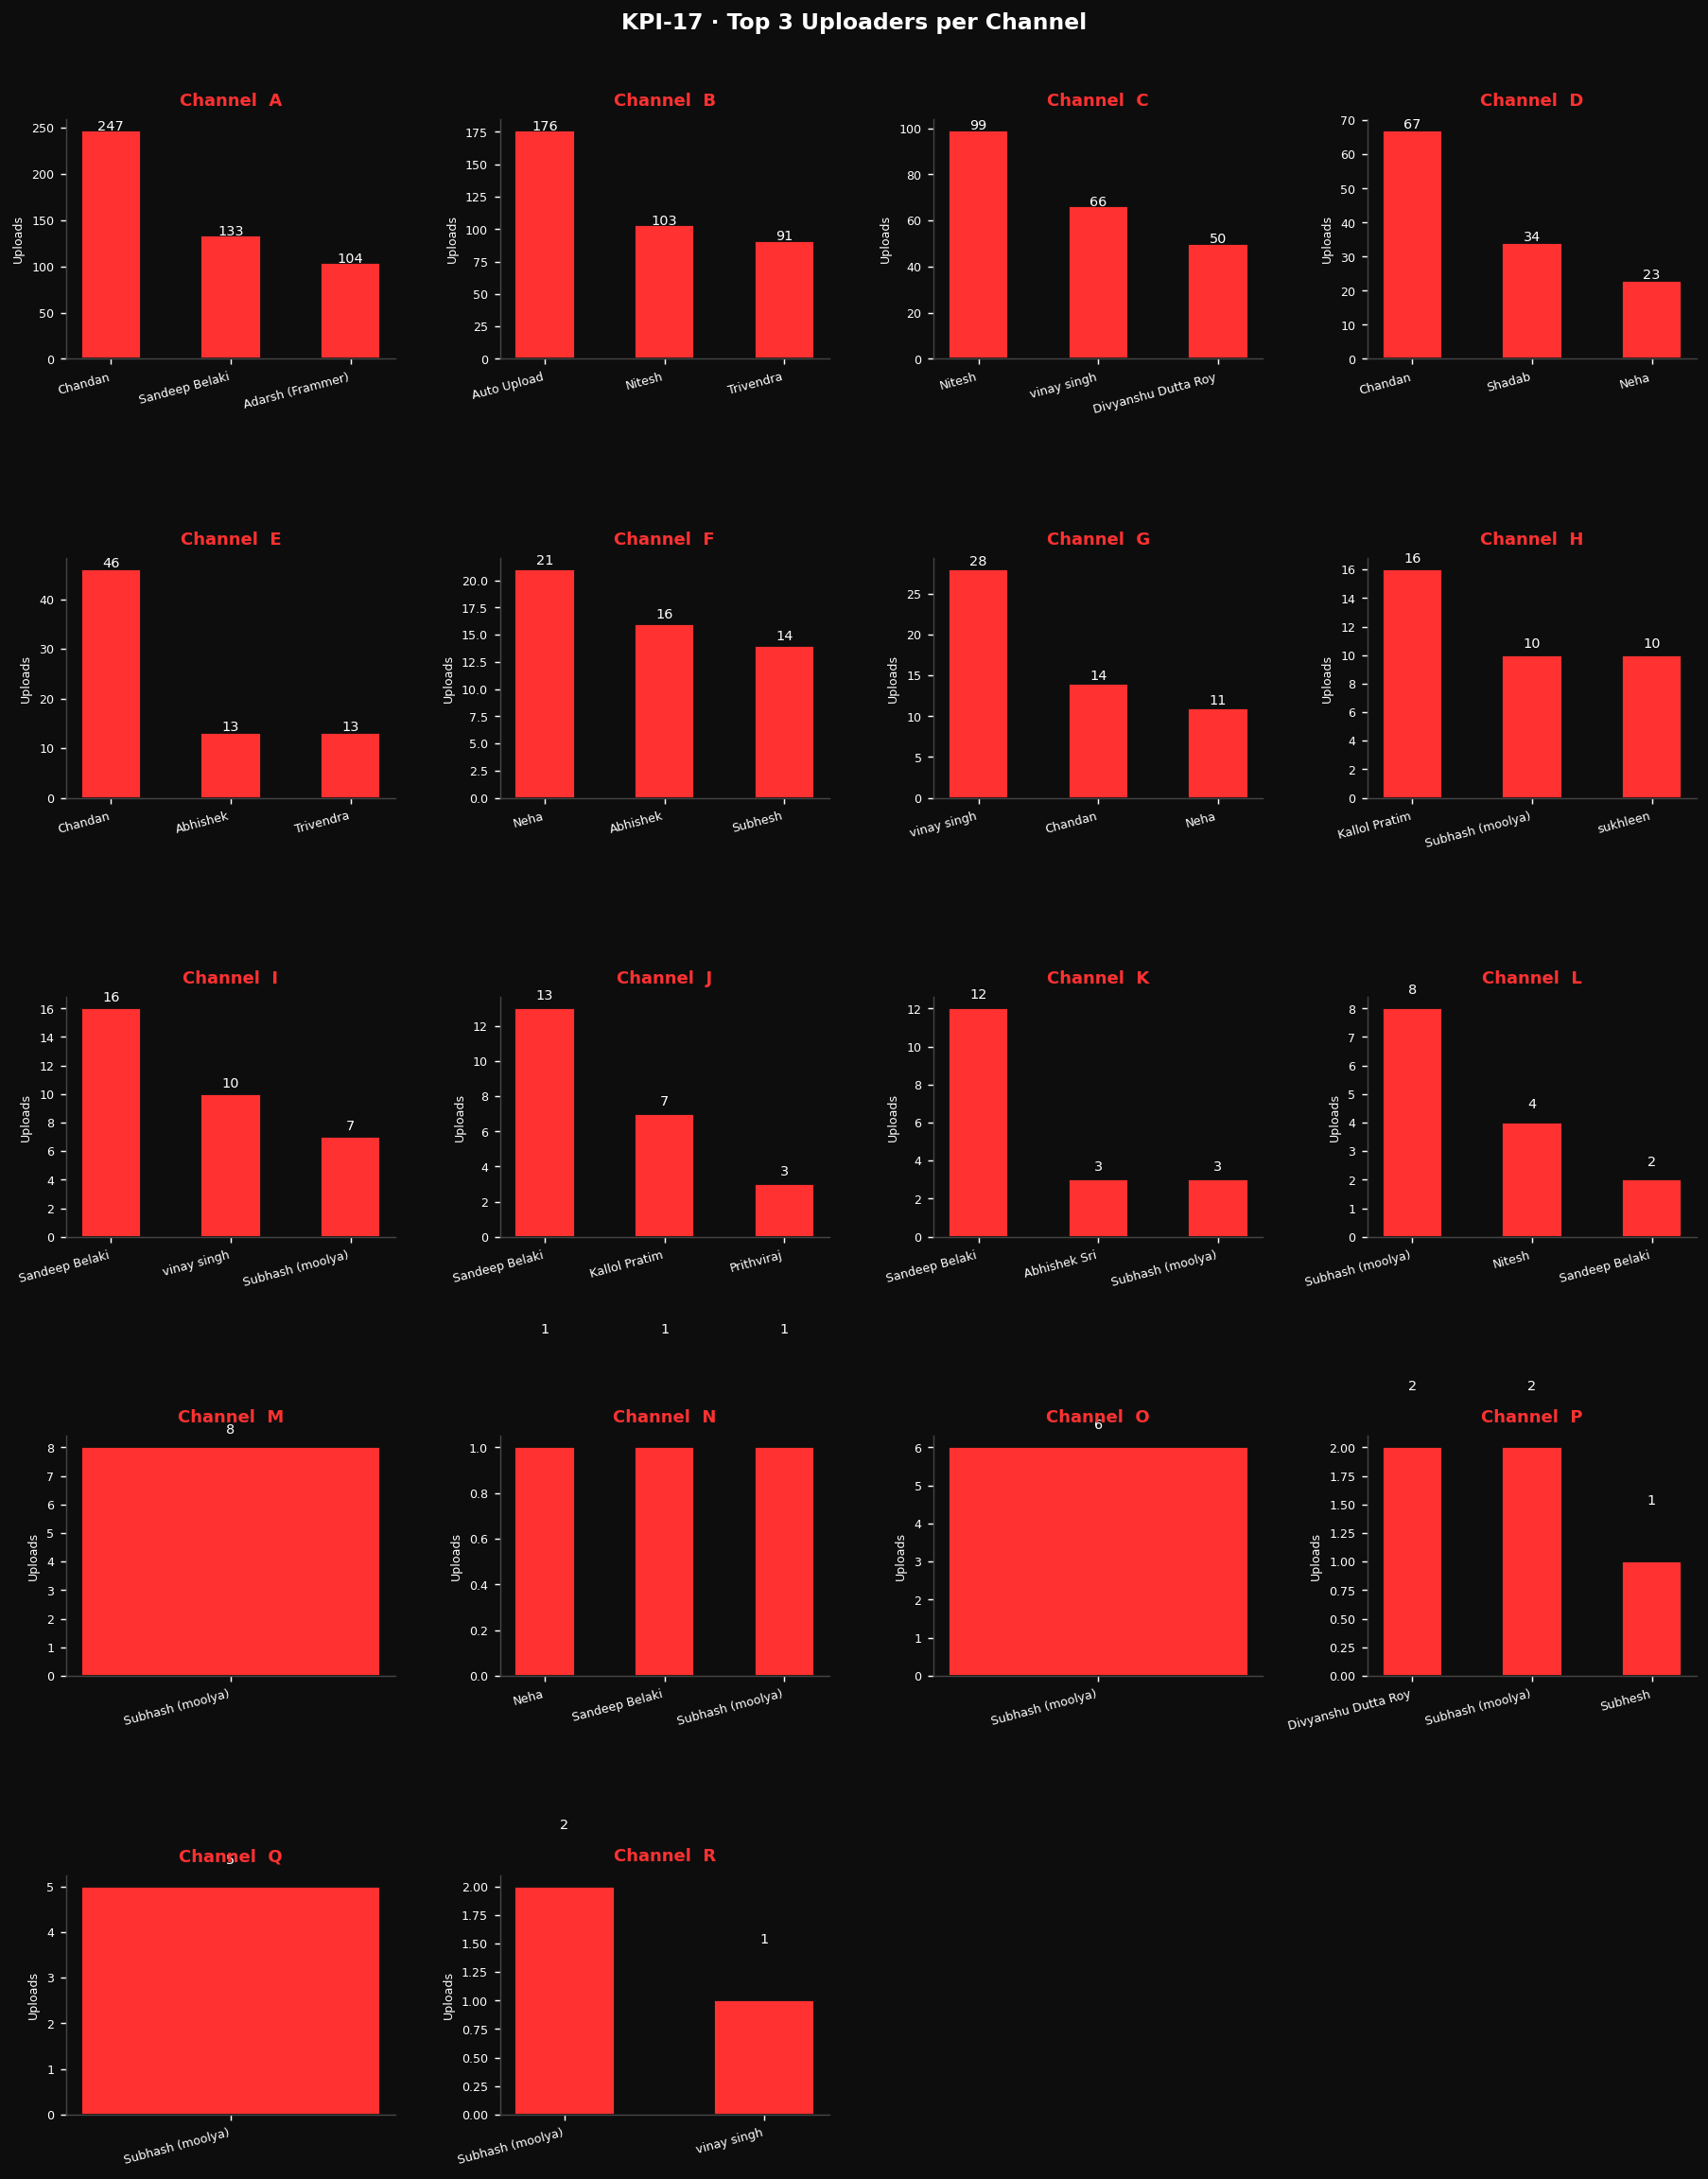

In [ ]:
# ── Top 3 uploaders per channel ───────────────────────────────────────────────
top3_uploaders = (
    df_clean.groupby(["Channel", "User"])["uploaded_cnt"]
    .sum()
    .reset_index()
    .groupby("Channel")
    .apply(lambda g: g.nlargest(3, "uploaded_cnt"))
    .reset_index(drop=True)
)

channels = top3_uploaders["Channel"].unique()
n_cols   = 4
n_rows   = int(np.ceil(len(channels) / n_cols))

# ── Small Multiples Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, n_rows * 3.5),
                          facecolor="#0D0D0D")
axes = axes.flatten()

for i, ch in enumerate(channels):
    ax  = axes[i]
    sub = top3_uploaders[top3_uploaders["Channel"] == ch].sort_values("uploaded_cnt", ascending=False)

    bars = ax.bar(sub["User"], sub["uploaded_cnt"],
                  color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.5)

    # Value labels on top
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(int(bar.get_height())),
                ha="center", fontsize=8, color="#FFFFFF")

    ax.set_title(f"Channel  {ch}", fontsize=10,
                 fontweight="bold", color="#FF3131", pad=8)
    ax.set_ylabel("Uploads", fontsize=7, color="#FFFFFF")
    ax.set_facecolor("#0D0D0D")
    ax.tick_params(colors="#FFFFFF", labelsize=7)
    ax.spines["bottom"].set_color("#444444")
    ax.spines["left"].set_color("#444444")

    # Wrap long usernames
    ax.set_xticklabels(sub["User"], rotation=15, ha="right", fontsize=7)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("KPI-17 · Top 3 Uploaders per Channel",
             fontsize=13, fontweight="bold",
             color="#FFFFFF", y=1.01)

plt.tight_layout()
plt.show()

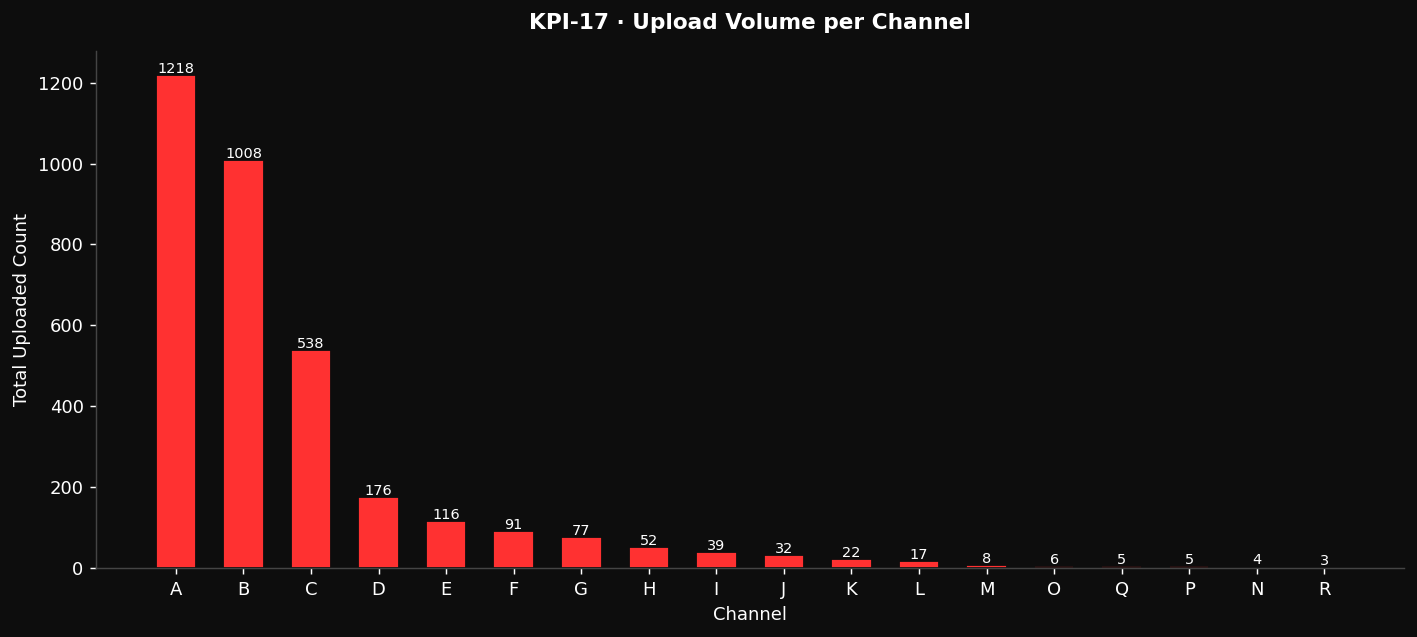

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi17 = (
    df_clean.groupby("Channel")["uploaded_cnt"]
    .sum()
    .reset_index()
    .rename(columns={"uploaded_cnt": "total_uploads"})
    .sort_values("total_uploads", ascending=False)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(kpi17["Channel"], kpi17["total_uploads"],
              color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.6)

# Value labels on top
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha="center", fontsize=8, color="#FFFFFF")

ax.set_xlabel("Channel")
ax.set_ylabel("Total Uploaded Count")
ax.set_title("KPI-17 · Upload Volume per Channel",
             fontsize=12, fontweight="bold", pad=12)
ax.set_facecolor("#0D0D0D")
fig.patch.set_facecolor("#0D0D0D")

plt.tight_layout()
plt.show()

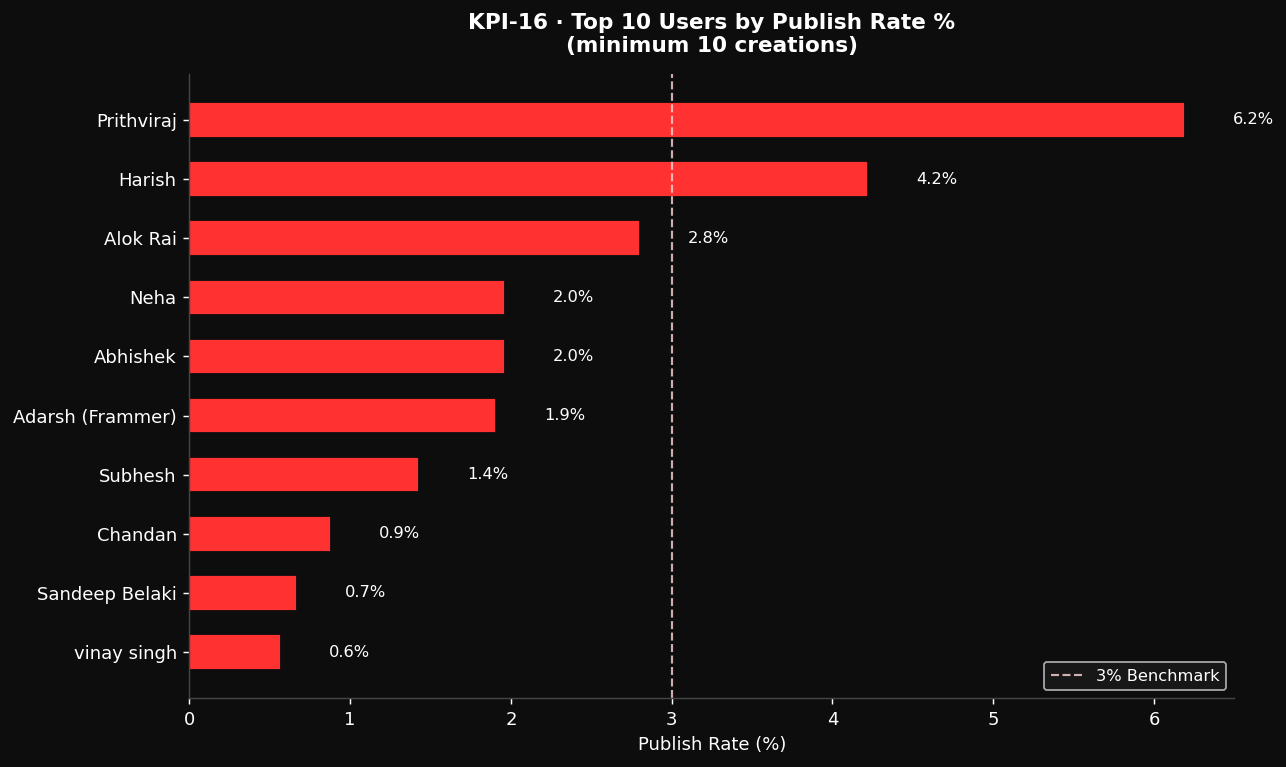

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi16 = (
    df_clean.groupby("User")
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)

# Min 10 creations for statistical validity
kpi16 = kpi16[kpi16["total_created"] >= 10].copy()

kpi16["user_publish_rate"] = (
    kpi16["total_published"] / kpi16["total_created"] * 100
).round(2)

top10 = kpi16.nlargest(10, "user_publish_rate").sort_values("user_publish_rate", ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10["User"], top10["user_publish_rate"],
               color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", height=0.6)

# Value labels
for bar, val in zip(bars, top10["user_publish_rate"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center",
            fontsize=9, color="#FFFFFF")

# 3% benchmark
ax.axvline(3, color=FRAMMER_COLORS[4], linestyle="--",
           linewidth=1.2, alpha=0.8, label="3% Benchmark")

ax.set_xlabel("Publish Rate (%)")
ax.set_title("KPI-16 · Top 10 Users by Publish Rate %\n(minimum 10 creations)",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, facecolor="#1A1A1A", labelcolor="#FFFFFF")
ax.set_facecolor("#0D0D0D")
fig.patch.set_facecolor("#0D0D0D")

plt.tight_layout()
plt.show()

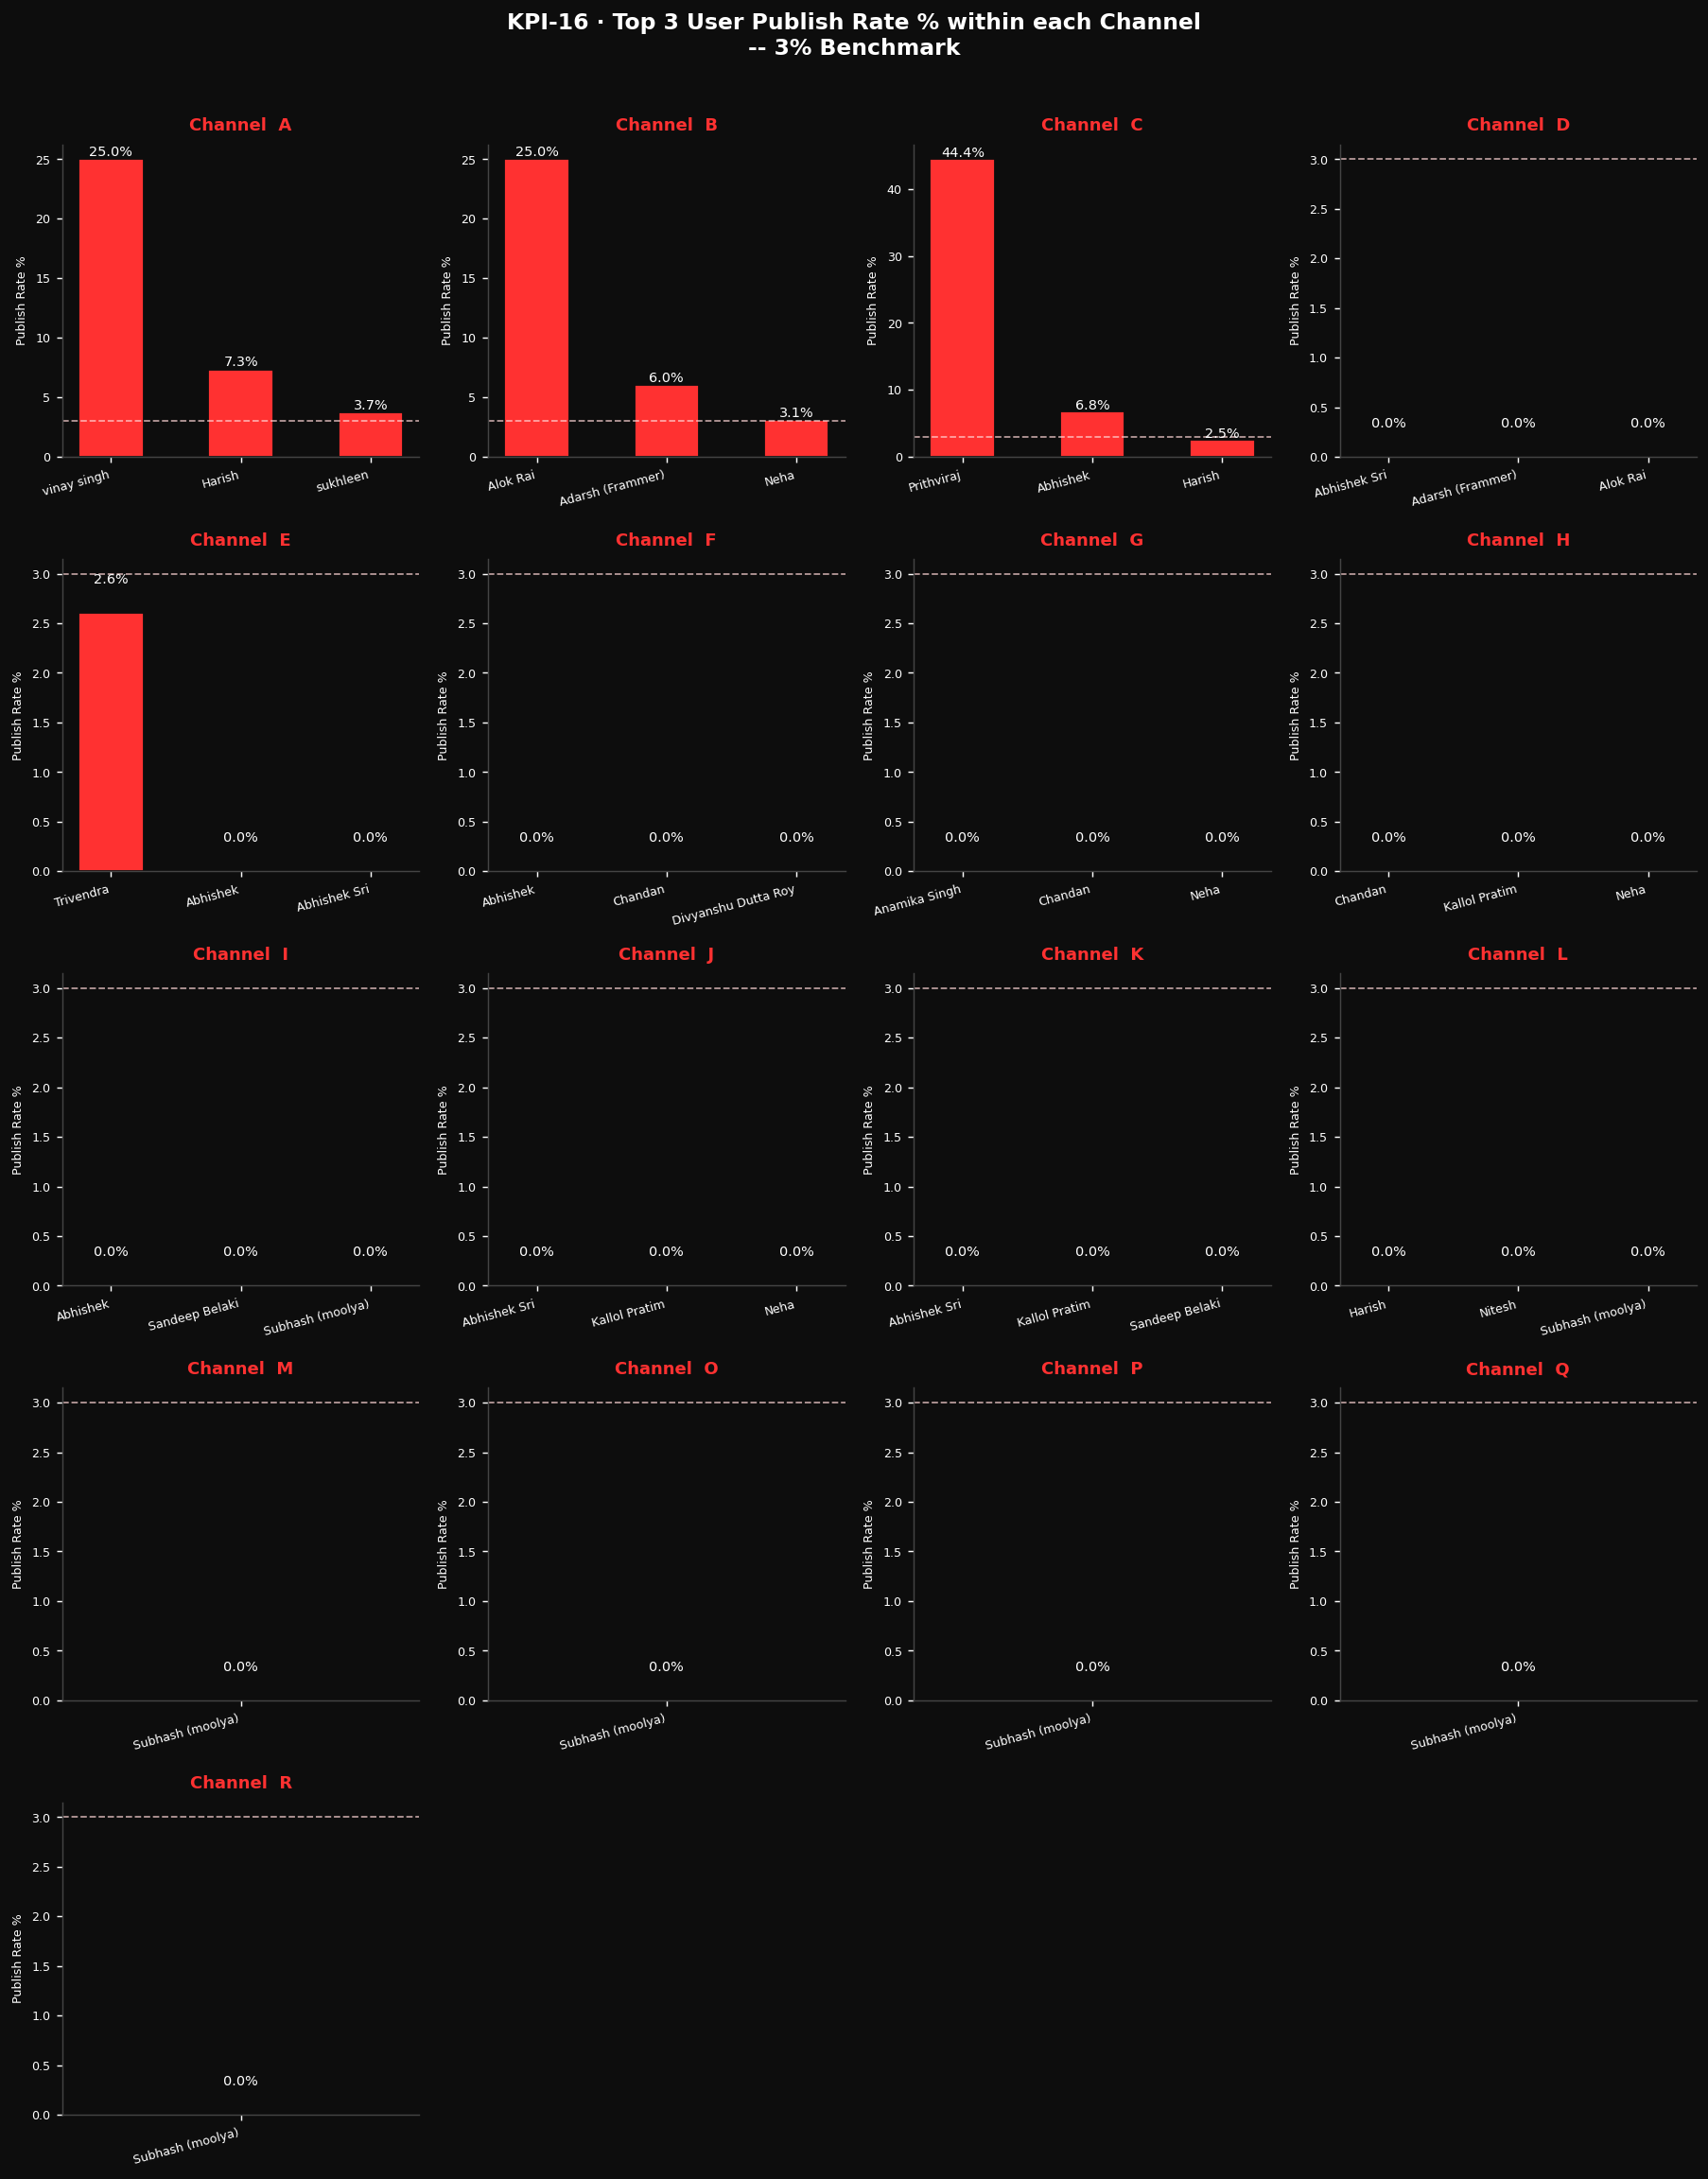

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi16_channel = (
    df_clean.groupby(["Channel", "User"])
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)

# Min 5 creations per channel for validity
kpi16_channel = kpi16_channel[kpi16_channel["total_created"] >= 5].copy()

kpi16_channel["user_publish_rate"] = (
    kpi16_channel["total_published"] / kpi16_channel["total_created"] * 100
).round(2)

# Top 3 users per channel by publish rate
top3_rate = (
    kpi16_channel.groupby("Channel")
    .apply(lambda g: g.nlargest(3, "user_publish_rate"))
    .reset_index(drop=True)
)

channels = top3_rate["Channel"].unique()
n_cols   = 4
n_rows   = int(np.ceil(len(channels) / n_cols))

# ── Small Multiples Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, n_rows * 3.5),
                          facecolor="#0D0D0D")
axes = axes.flatten()

for i, ch in enumerate(channels):
    ax  = axes[i]
    sub = top3_rate[top3_rate["Channel"] == ch].sort_values("user_publish_rate", ascending=False)

    bars = ax.bar(sub["User"], sub["user_publish_rate"],
                  color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.5)

    # Value labels on top
    for bar, val in zip(bars, sub["user_publish_rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", fontsize=8, color="#FFFFFF")

    # 3% benchmark
    ax.axhline(3, color=FRAMMER_COLORS[4], linestyle="--",
               linewidth=1, alpha=0.7)

    ax.set_title(f"Channel  {ch}", fontsize=10,
                 fontweight="bold", color="#FF3131", pad=8)
    ax.set_ylabel("Publish Rate %", fontsize=7, color="#FFFFFF")
    ax.set_facecolor("#0D0D0D")
    ax.tick_params(colors="#FFFFFF", labelsize=7)
    ax.spines["bottom"].set_color("#444444")
    ax.spines["left"].set_color("#444444")
    ax.set_xticklabels(sub["User"], rotation=15, ha="right", fontsize=7)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("KPI-16 · Top 3 User Publish Rate % within each Channel\n-- 3% Benchmark",
             fontsize=13, fontweight="bold",
             color="#FFFFFF", y=1.01)

plt.tight_layout()
plt.show()

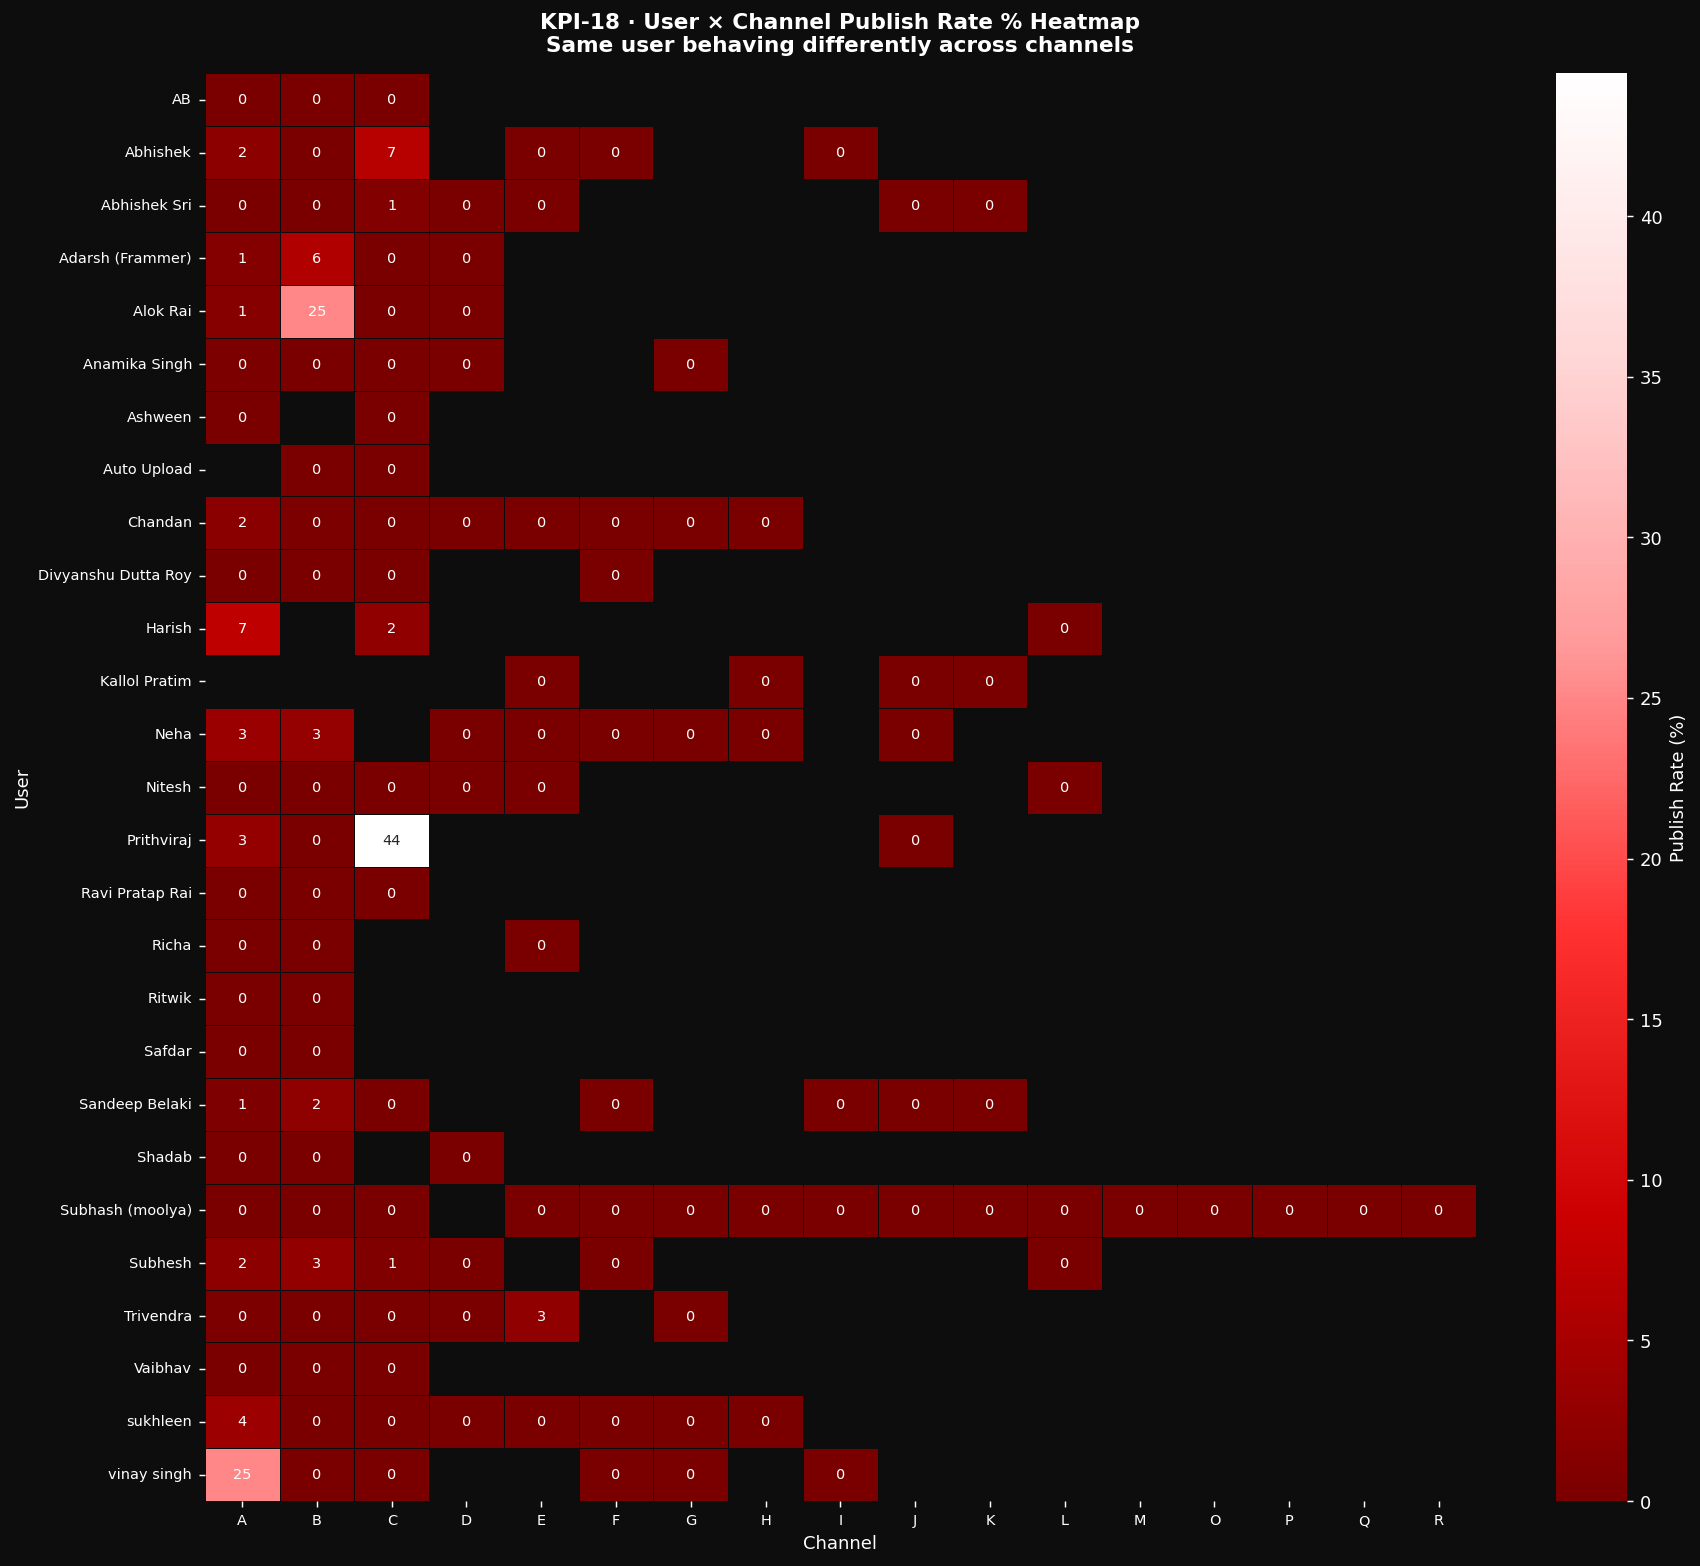

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi18 = (
    df_clean.groupby(["Channel", "User"])
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)

kpi18 = kpi18[kpi18["total_created"] >= 5].copy()

kpi18["user_publish_rate"] = (
    kpi18["total_published"] / kpi18["total_created"] * 100
).round(2)

pivot = kpi18.pivot_table(index="User", columns="Channel",
                           values="user_publish_rate",
                           fill_value=np.nan)

pivot = pivot[pivot.notna().sum(axis=1) >= 2]

# ── Custom Frammer Colormap ───────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

frammer_cmap = LinearSegmentedColormap.from_list(
    "frammer", ["#7A0000", "#CC0000", "#FF3131", "#FF9A9A", "#FFD6D6", "#FFFFFF"]
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.45)))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap=frammer_cmap,
    linewidths=0.4,
    linecolor="#0D0D0D",
    cbar_kws={"label": "Publish Rate (%)"},
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title("KPI-18 · User × Channel Publish Rate % Heatmap\n"
             "Same user behaving differently across channels",
             fontsize=12, fontweight="bold", pad=12, color="#FFFFFF")
ax.set_xlabel("Channel", color="#FFFFFF")
ax.set_ylabel("User", color="#FFFFFF")
ax.tick_params(colors="#FFFFFF", labelsize=8)
ax.figure.axes[-1].tick_params(colors="#FFFFFF")
ax.figure.axes[-1].yaxis.label.set_color("#FFFFFF")

fig.patch.set_facecolor("#0D0D0D")
ax.set_facecolor("#0D0D0D")

plt.tight_layout()
plt.show()

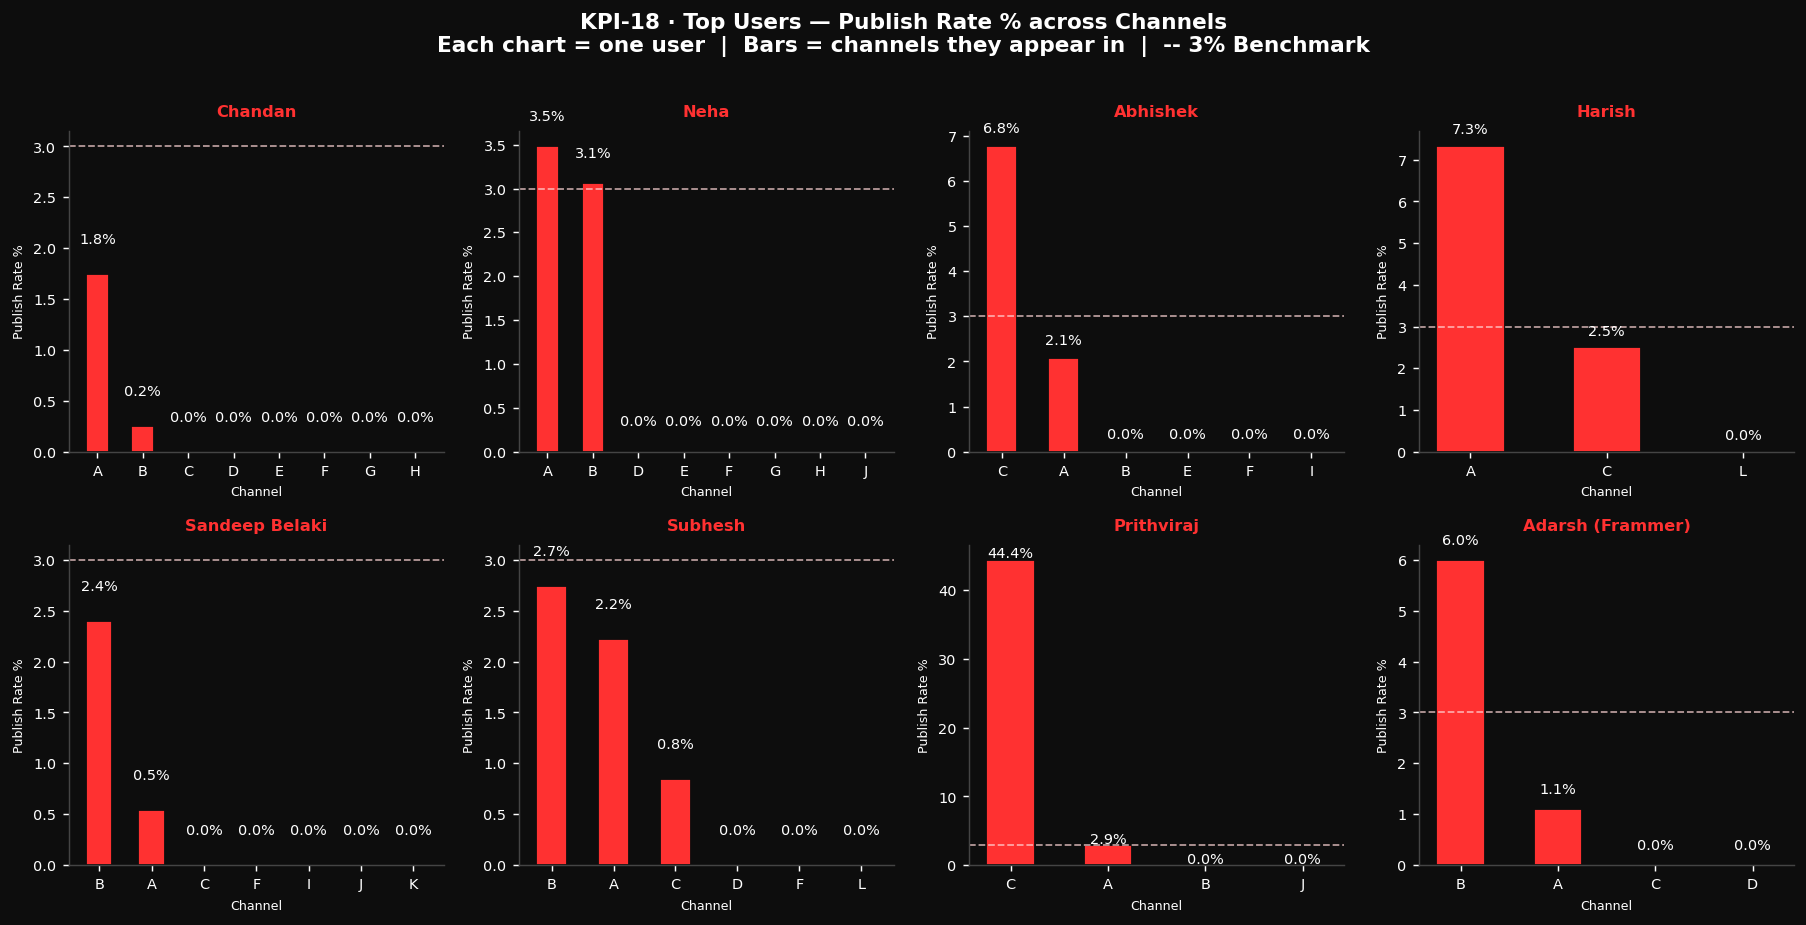

In [ ]:
# ── Calculation ───────────────────────────────────────────────────────────────
kpi18_sm = (
    df_clean.groupby(["Channel", "User"])
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)

kpi18_sm = kpi18_sm[kpi18_sm["total_created"] >= 5].copy()

kpi18_sm["user_publish_rate"] = (
    kpi18_sm["total_published"] / kpi18_sm["total_created"] * 100
).round(2)

# Top 8 users by total published count
top_users = (
    kpi18_sm.groupby("User")["total_published"]
    .sum()
    .nlargest(8)
    .index
)
kpi18_sm = kpi18_sm[kpi18_sm["User"].isin(top_users)]

# ── Small Multiples — one chart per user ─────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(top_users) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, n_rows * 3.5),
                          facecolor="#0D0D0D")
axes = axes.flatten()

for i, user in enumerate(top_users):
    ax  = axes[i]
    sub = (
        kpi18_sm[kpi18_sm["User"] == user]
        .sort_values("user_publish_rate", ascending=False)
    )

    bars = ax.bar(sub["Channel"], sub["user_publish_rate"],
                  color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.5)

    # Value labels on top
    for bar, val in zip(bars, sub["user_publish_rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", fontsize=8, color="#FFFFFF")

    # 3% benchmark
    ax.axhline(3, color=FRAMMER_COLORS[4], linestyle="--",
               linewidth=1, alpha=0.7)

    ax.set_title(user, fontsize=9,
                 fontweight="bold", color="#FF3131", pad=8)
    ax.set_xlabel("Channel", fontsize=7, color="#FFFFFF")
    ax.set_ylabel("Publish Rate %", fontsize=7, color="#FFFFFF")
    ax.set_facecolor("#0D0D0D")
    ax.tick_params(colors="#FFFFFF", labelsize=8)
    ax.spines["bottom"].set_color("#444444")
    ax.spines["left"].set_color("#444444")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("KPI-18 · Top Users — Publish Rate % across Channels\n"
             "Each chart = one user  |  Bars = channels they appear in  |  -- 3% Benchmark",
             fontsize=12, fontweight="bold",
             color="#FFFFFF", y=1.01)

plt.tight_layout()
plt.show()

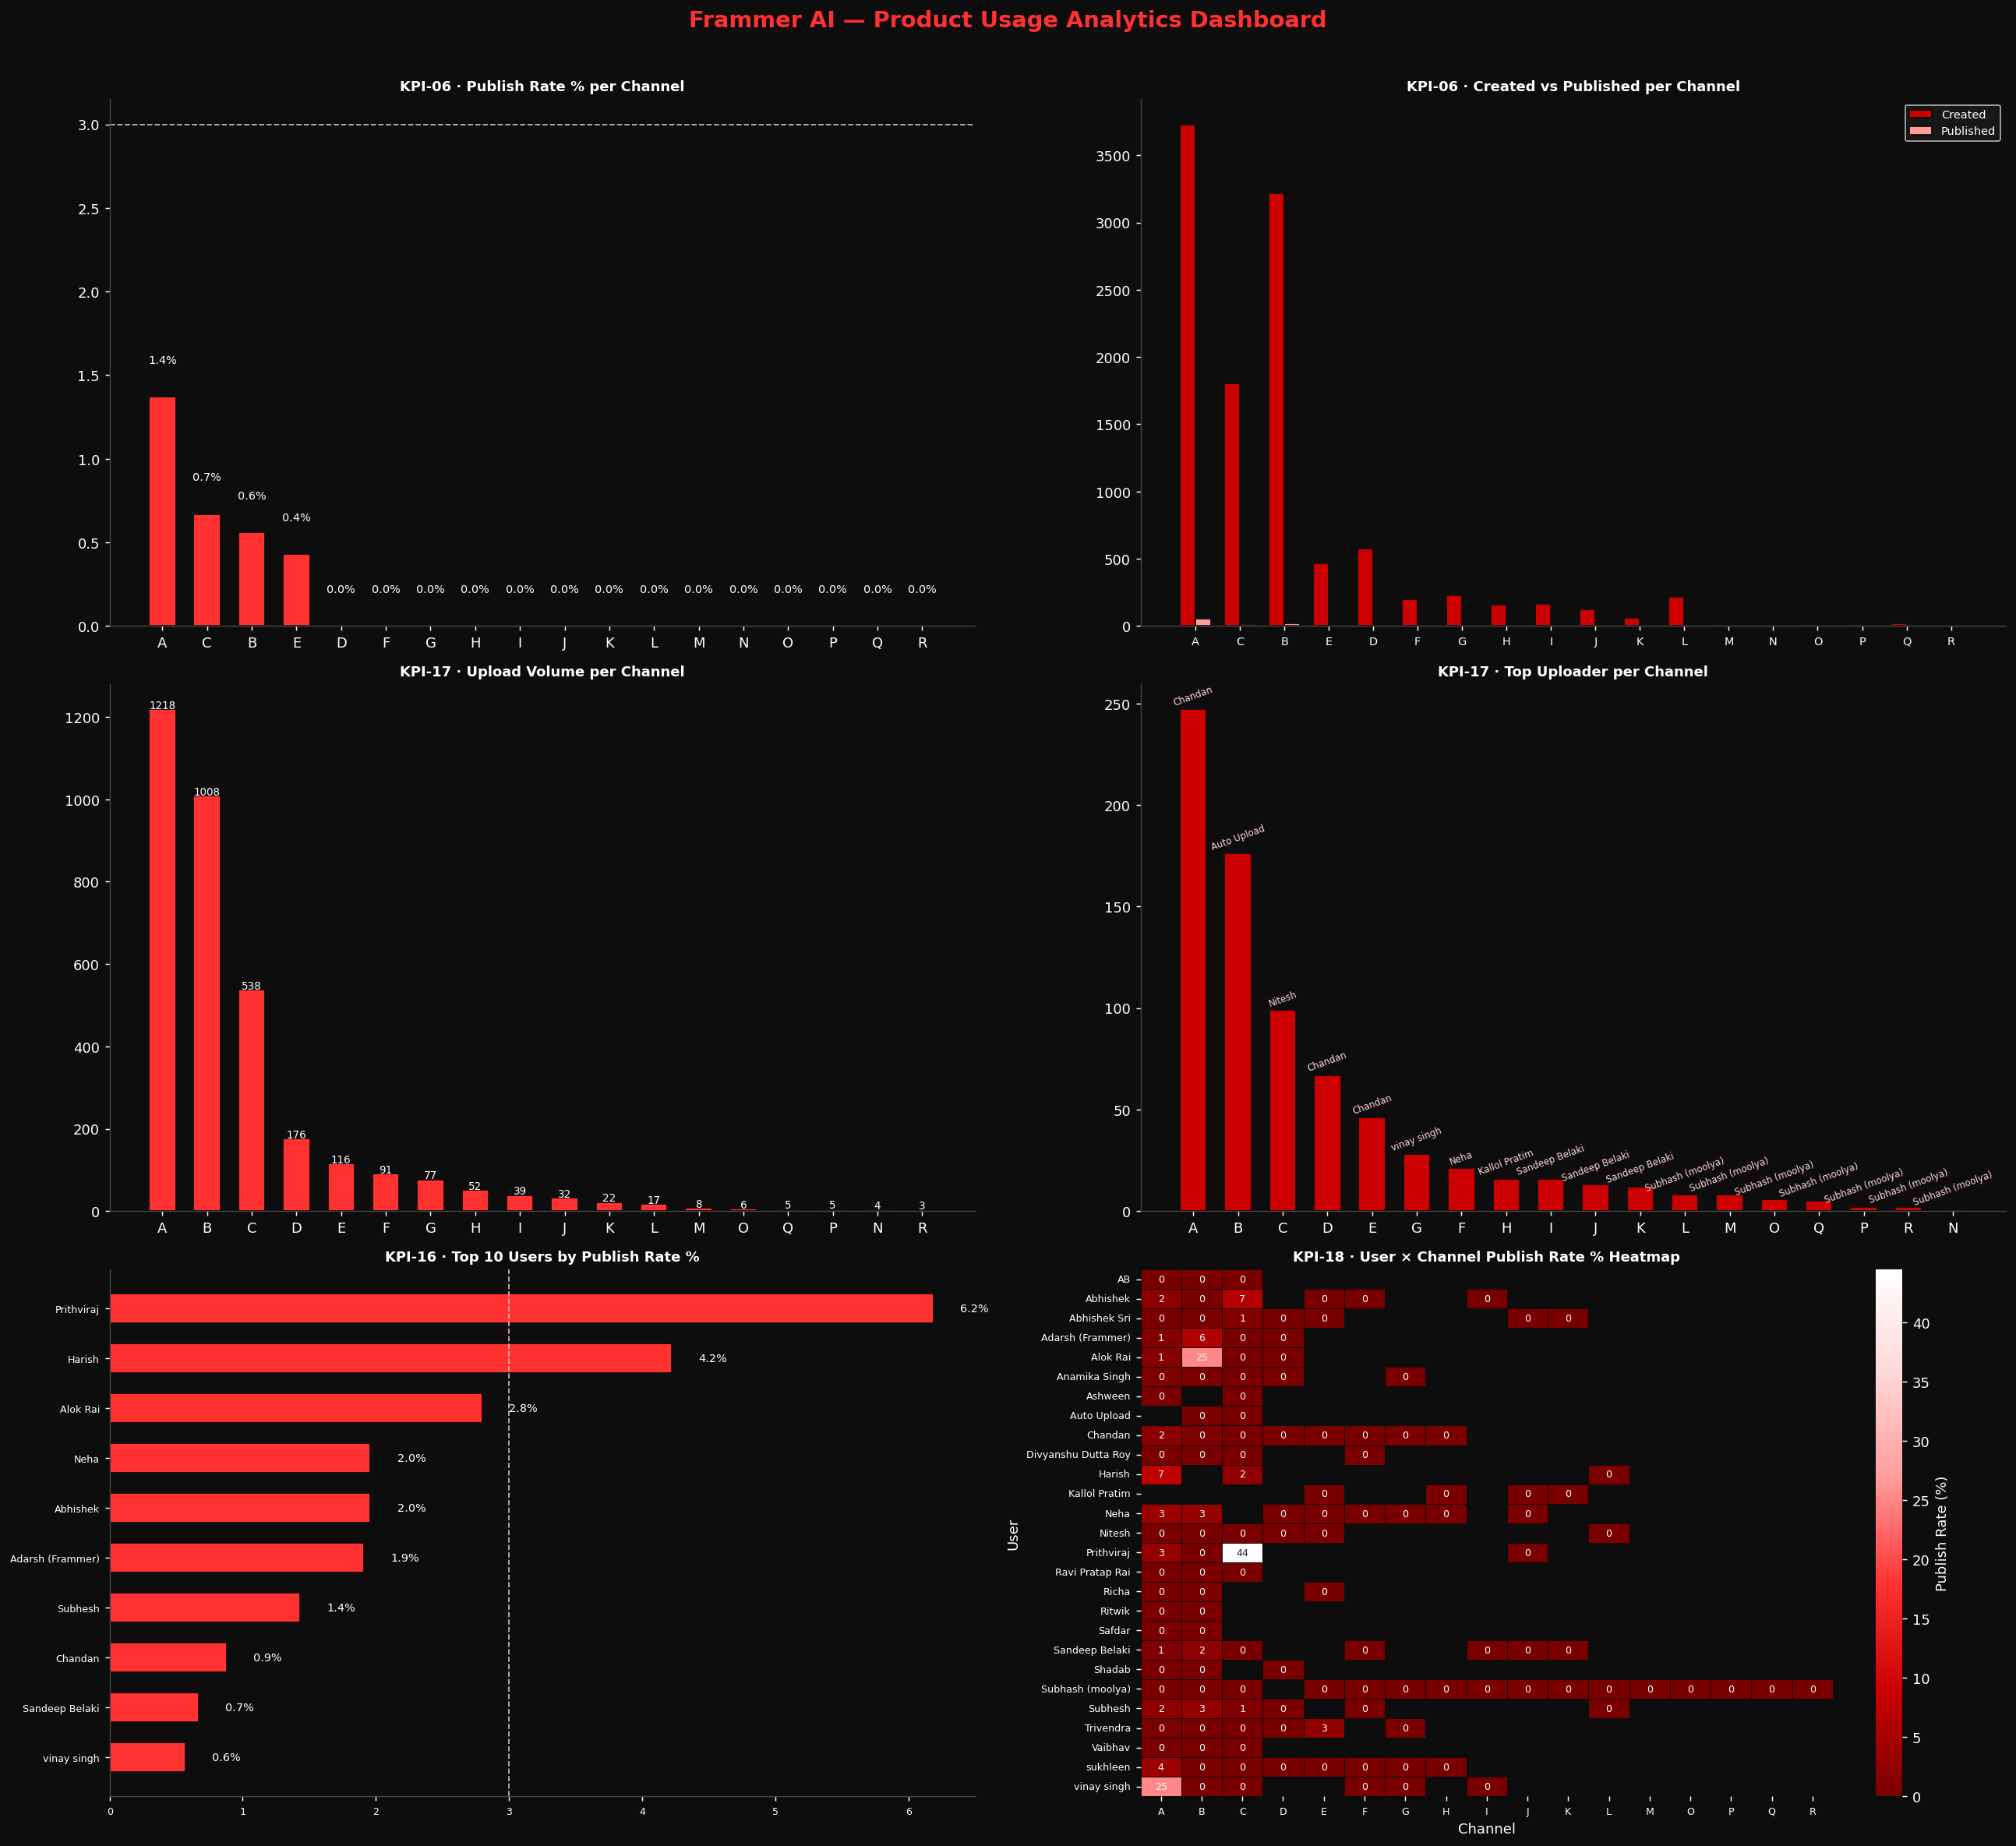

In [ ]:
# ── Pre-compute all KPIs ──────────────────────────────────────────────────────

# KPI-06
kpi06 = (
    df_clean.groupby("Channel")
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .assign(publish_rate_pct=lambda x:
            (x["total_published"] / x["total_created"] * 100).round(2))
    .reset_index()
    .sort_values("publish_rate_pct", ascending=False)
)

# KPI-17
kpi17 = (
    df_clean.groupby("Channel")["uploaded_cnt"]
    .sum().reset_index()
    .rename(columns={"uploaded_cnt": "total_uploads"})
    .sort_values("total_uploads", ascending=False)
)

top_uploader = (
    df_clean.groupby(["Channel", "User"])["uploaded_cnt"]
    .sum().reset_index()
    .sort_values("uploaded_cnt", ascending=False)
    .groupby("Channel").first().reset_index()
    .rename(columns={"uploaded_cnt": "top_uploads"})
    .sort_values("top_uploads", ascending=False)
)

# KPI-16
kpi16 = (
    df_clean.groupby("User")
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)
kpi16 = kpi16[kpi16["total_created"] >= 10].copy()
kpi16["user_publish_rate"] = (
    kpi16["total_published"] / kpi16["total_created"] * 100
).round(2)
top10 = kpi16.nlargest(10, "user_publish_rate").sort_values("user_publish_rate", ascending=True)

# KPI-18 Heatmap
from matplotlib.colors import LinearSegmentedColormap
frammer_cmap = LinearSegmentedColormap.from_list(
    "frammer", ["#7A0000", "#CC0000", "#FF3131", "#FF9A9A", "#FFD6D6", "#FFFFFF"]
)

kpi18 = (
    df_clean.groupby(["Channel", "User"])
    .agg(total_published=("published_cnt", "sum"),
         total_created  =("created_cnt",   "sum"))
    .reset_index()
)
kpi18 = kpi18[kpi18["total_created"] >= 5].copy()
kpi18["user_publish_rate"] = (
    kpi18["total_published"] / kpi18["total_created"] * 100
).round(2)
pivot = kpi18.pivot_table(index="User", columns="Channel",
                           values="user_publish_rate", fill_value=np.nan)
pivot = pivot[pivot.notna().sum(axis=1) >= 2]

# ── Dashboard Layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18), facecolor="#0D0D0D")
fig.suptitle("Frammer AI — Product Usage Analytics Dashboard",
             fontsize=16, fontweight="bold",
             color="#FF3131", y=1.01)

# ── Panel 1 · KPI-06 Publish Rate % per Channel ───────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
bars = ax1.bar(kpi06["Channel"], kpi06["publish_rate_pct"],
               color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.6)
for bar, val in zip(bars, kpi06["publish_rate_pct"]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{val:.1f}%", ha="center", fontsize=8, color="#FFFFFF")
ax1.axhline(3, color=FRAMMER_COLORS[4], linestyle="--", linewidth=1, alpha=0.8)
ax1.set_title("KPI-06 · Publish Rate % per Channel",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax1.set_facecolor("#0D0D0D")
ax1.tick_params(colors="#FFFFFF")

# ── Panel 2 · KPI-06 Created vs Published ─────────────────────────────────────
ax2   = fig.add_subplot(3, 2, 2)
x     = np.arange(len(kpi06))
width = 0.35
ax2.bar(x - width/2, kpi06["total_created"],   width,
        color=FRAMMER_COLORS[1], edgecolor="#0D0D0D", label="Created")
ax2.bar(x + width/2, kpi06["total_published"], width,
        color=FRAMMER_COLORS[3], edgecolor="#0D0D0D", label="Published")
ax2.set_xticks(x)
ax2.set_xticklabels(kpi06["Channel"], fontsize=8)
ax2.set_title("KPI-06 · Created vs Published per Channel",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax2.legend(fontsize=8, facecolor="#1A1A1A", labelcolor="#FFFFFF")
ax2.set_facecolor("#0D0D0D")
ax2.tick_params(colors="#FFFFFF")

# ── Panel 3 · KPI-17 Upload Volume per Channel ────────────────────────────────
ax3  = fig.add_subplot(3, 2, 3)
bars = ax3.bar(kpi17["Channel"], kpi17["total_uploads"],
               color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", width=0.6)
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 2,
             str(int(bar.get_height())),
             ha="center", fontsize=7.5, color="#FFFFFF")
ax3.set_title("KPI-17 · Upload Volume per Channel",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax3.set_facecolor("#0D0D0D")
ax3.tick_params(colors="#FFFFFF")

# ── Panel 4 · KPI-17 Top Uploader per Channel ─────────────────────────────────
ax4  = fig.add_subplot(3, 2, 4)
bars = ax4.bar(top_uploader["Channel"], top_uploader["top_uploads"],
               color=FRAMMER_COLORS[1], edgecolor="#0D0D0D", width=0.6)
for bar, row in zip(bars, top_uploader.itertuples()):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             row.User, ha="center", va="bottom",
             fontsize=6.5, color="#FFD6D6", rotation=20)
ax4.set_title("KPI-17 · Top Uploader per Channel",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax4.set_facecolor("#0D0D0D")
ax4.tick_params(colors="#FFFFFF")

# ── Panel 5 · KPI-16 Top 10 Users by Publish Rate ─────────────────────────────
ax5  = fig.add_subplot(3, 2, 5)
bars = ax5.barh(top10["User"], top10["user_publish_rate"],
                color=FRAMMER_COLORS[2], edgecolor="#0D0D0D", height=0.6)
for bar, val in zip(bars, top10["user_publish_rate"]):
    ax5.text(bar.get_width() + 0.2,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=8, color="#FFFFFF")
ax5.axvline(3, color=FRAMMER_COLORS[4], linestyle="--", linewidth=1, alpha=0.8)
ax5.set_title("KPI-16 · Top 10 Users by Publish Rate %",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax5.set_facecolor("#0D0D0D")
ax5.tick_params(colors="#FFFFFF", labelsize=7)

# ── Panel 6 · KPI-18 Heatmap ──────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
sns.heatmap(pivot, annot=True, fmt=".0f",
            cmap=frammer_cmap,
            linewidths=0.4, linecolor="#0D0D0D",
            cbar_kws={"label": "Publish Rate (%)"},
            ax=ax6, annot_kws={"size": 7})
ax6.set_title("KPI-18 · User × Channel Publish Rate % Heatmap",
              fontsize=10, fontweight="bold", color="#FFFFFF")
ax6.set_facecolor("#0D0D0D")
ax6.tick_params(colors="#FFFFFF", labelsize=7)
ax6.figure.axes[-1].tick_params(colors="#FFFFFF")
ax6.figure.axes[-1].yaxis.label.set_color("#FFFFFF")

plt.tight_layout()
plt.show()